In [1]:
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

"""
0: Move left

1: Move down

2: Move right

3: Move up
"""


GAMMA = 0.99
MAX_EVAL_ITERS = 10
NUM_MC_EPISODES = 300
MAX_ITER = 4000
NUM_EPISODES = 2000

SIZE = 8

In [2]:
def build_env(map_name: str = f"{SIZE}x{SIZE}", slippery: bool = True):
    # Fixed the reward_schedule error (Gymnasium FrozenLake doesn't accept reward_schedule by default)
    return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery, reward_schedule=(10, -5, -0.2))


def extract_model(env: gym.Env):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    transition = np.zeros((n_states, n_actions, n_states), dtype=float)
    reward = np.zeros((n_states, n_actions, n_states), dtype=float)

    for state in range(n_states):
        for action in range(n_actions):
            for prob, next_state, r, _terminated in env.unwrapped.P[state][action]:
                transition[state, action, next_state] += prob
                reward[state, action, next_state] = r

    expected_reward = np.sum(transition * reward, axis=2)
    return transition, reward, expected_reward

In [3]:
def policy_iter(env, eval_method, num_iterations=MAX_ITER):
    policy = np.zeros((env.observation_space.n), dtype=int)
    safe_states = []
    for i in range(env.observation_space.n):
        row, col = divmod(i, SIZE)
        # print(str(env.unwrapped.desc[row, col]))
        if env.unwrapped.desc[row, col] in [b'S', b'F']:
            safe_states.append(i)

    for iter in range(num_iterations):
        if iter % 100 == 0:
          print(f"Iteration: {iter}")
        q_matrix, episode_rewards, episode_lengths = eval_method(env, policy, safe_states=safe_states)
        new_policy = np.argmax(q_matrix, axis=1)

        if np.array_equal(policy, new_policy):
            print("Converged")
            break

        policy = new_policy

    return policy, episode_rewards, episode_lengths

In [4]:
def q_values_from_values(transition_matrix, reward_matrix, value_matrix):
    # reward: s x a x s
    # transition: s x a x s
    # value: s
    q_values = np.sum(reward_matrix * transition_matrix, axis=2) + GAMMA * np.einsum("sat, t -> sa", transition_matrix, value_matrix)
    return q_values

In [5]:
def plot_frozenlake_policy(policy, desc):
    """
    policy: (N,N) array of actions
    desc:   (N,N) array containing b'S', b'F', b'H', b'G'
    """

    nrows, ncols = desc.shape

    fig, ax = plt.subplots(figsize=(ncols, nrows))

    arrows = {
        0: "←",  # left
        1: "↓",  # down
        2: "→",  # right
        3: "↑",  # up
    }

    for r in range(nrows):
        for c in range(ncols):

            tile = desc[r, c]

            # background color
            if tile == b'H':
                color = "black"
            elif tile == b'G':
                color = "green"
            elif tile == b'S':
                color = "lightblue"
            else:
                color = "white"

            rect = plt.Rectangle(
                (c, nrows - r - 1),
                1,
                1,
                facecolor=color,
                edgecolor="gray",
            )
            ax.add_patch(rect)

            if tile == b'H':
                ax.text(
                    c + 0.5,
                    nrows - r - 0.5,
                    "H",
                    ha="center",
                    va="center",
                    fontsize=18,
                    color="white",
                    fontweight="bold",
                )

            elif tile == b'G':
                ax.text(
                    c + 0.5,
                    nrows - r - 0.5,
                    "G",
                    ha="center",
                    va="center",
                    fontsize=18,
                    fontweight="bold",
                )

            else:
                ax.text(
                    c + 0.5,
                    nrows - r - 0.5,
                    arrows[policy[r, c]],
                    ha="center",
                    va="center",
                    fontsize=20,
                )

    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

In [6]:
"""My understanding of importance sampling

2 types of PI methods, on and off policy. On means i generate and then evaluate using the same policy,
was the reason greedy montecarlo failed earlier when i started with all 0 policy

off policy means i generate experiences wtih one policy (eg. e-greedy) but want to use those exp
to evaluate another policy, like pure greedy. epsilon-greedy MC or SARA we used are off policy

problem here is that its 'dishonest' to use a different policy for experiences, as it would take actions
that my policy being evaluated (target) would never take. Hence, we wadd weights to experiences steps,

weight of each trajectory under importance sampling is product(prob_target(si | ai)/prob_behaviour(si_ai))
where behaviour is the policy used to generate episodes/trajectories

"""

"My understanding of importance sampling\n\n2 types of PI methods, on and off policy. On means i generate and then evaluate using the same policy,\nwas the reason greedy montecarlo failed earlier when i started with all 0 policy\n\noff policy means i generate experiences wtih one policy (eg. e-greedy) but want to use those exp\nto evaluate another policy, like pure greedy. epsilon-greedy MC or SARA we used are off policy\n\nproblem here is that its 'dishonest' to use a different policy for experiences, as it would take actions\nthat my policy being evaluated (target) would never take. Hence, we wadd weights to experiences steps,\n\nweight of each trajectory under importance sampling is product(prob_target(si | ai)/prob_behaviour(si_ai))\nwhere behaviour is the policy used to generate episodes/trajectories\n\n"

In [7]:
def mc_eval_importance_sampling(env, policy, num_episodes=NUM_MC_EPISODES, max_iter=MAX_EVAL_ITERS, safe_states=None, eps=0.1):
    transition_matrix, reward_matrix, expected_reward_matrix = extract_model(env)
    value_matrix = np.zeros((env.observation_space.n))
    returns = np.zeros((env.observation_space.n))
    return_sums = np.zeros((env.observation_space.n))

    episode_rewards = []   # total reward each episode
    episode_lengths = []   # number of steps each episode

    for episode in range(num_episodes):
        state, _ = env.reset()
        # Random choice to ensure coverage
        if safe_states is not None:
            env.unwrapped.s = random.choice(safe_states)
        else:
            env.unwrapped.s = random.choice(list(range(env.observation_space.n)))
        i = 0
        # print(env.unwrapped.s, ":", end=" ")
        terminated = truncated = False
        visited = []
        while i < max_iter and not terminated and not truncated:
            chance = np.random.uniform(0, 1)
            if chance > eps:
                action = policy[state]
            else:
                action = random.choice(np.arange(env.action_space.n))
            # print(action, end=" ")
            next_state, reward, terminated, truncated, _ = env.step(action)
            visited.append((state, reward, action))
            state = next_state
            i += 1

        episode_rewards.append(sum(r for _, r, _ in visited))
        episode_lengths.append(len(visited))
        G = 0

        """this part is confusing
        basically, on each episode, we find a value for each step with the GP experession,
        # but then add them to a record. Each states value is just the mean of all
        # these valeus over all eps

        episode_rewards.append(sum(r for _, r, _ in visited))
        episode_lengths.append(len(visited))

        # in importance sampling, we apply the weighting in this step
        # if we ever hit 0, then we leve the rest of the trajectory

        # however, looking at this, it seems pretty unstable, unlikely to get trajectories more than length 10
        # there's another weighted version i found, but that also doesn't give trajectories
        past the point where it hits 0?"""

        for (state, reward, action) in visited[::-1]:
            G = reward + GAMMA * G
            if action == policy[state]:
                G *= 1/(1-eps+eps/env.action_space.n)
                return_sums[state] += G
                returns[state] += 1
                value_matrix[state] = return_sums[state] / returns[state]
            else:
                return_sums[state] += G
                returns[state] += 1
                value_matrix[state] = return_sums[state] / returns[state]
                break

    q_values = q_values_from_values(transition_matrix, reward_matrix, value_matrix)
    return q_values, episode_rewards, episode_lengths

In [8]:
def plot_mc_stats(episode_rewards, episode_lengths, window=50):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    episodes = np.arange(1, len(episode_rewards) + 1)

    def smooth(data, w):
        kernel = np.ones(w) / w
        return np.convolve(data, kernel, mode='valid')

    configs = [
        (episode_rewards, "Average Reward per Episode", "Total Reward", "#4C9BE8"),
        (episode_lengths, "Average Episode Length",     "Steps",        "#E87B4C"),
    ]

    for ax, (raw, title, ylabel, color) in zip(axes, configs):
        smoothed = smooth(raw, window)
        smoothed_x = episodes[window - 1:]

        ax.plot(episodes, raw, alpha=0.25, color=color, linewidth=0.8, label="Raw")
        ax.plot(smoothed_x, smoothed, color=color, linewidth=2, label=f"{window}-ep moving avg")
        ax.set_title(title)
        ax.set_xlabel("Episode")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Iteration: 0
Iteration: 100
Iteration: 200
Iteration: 300
Iteration: 400
Iteration: 500
Iteration: 600
Iteration: 700
Iteration: 800
Iteration: 900
Iteration: 1000
Iteration: 1100
Iteration: 1200
Iteration: 1300
Iteration: 1400
Iteration: 1500
Iteration: 1600
Iteration: 1700
Iteration: 1800
Iteration: 1900
Iteration: 2000
Iteration: 2100
Iteration: 2200
Iteration: 2300
Iteration: 2400
Iteration: 2500
Iteration: 2600
Iteration: 2700
Iteration: 2800
Iteration: 2900
Iteration: 3000
Iteration: 3100
Iteration: 3200
Iteration: 3300
Iteration: 3400
Iteration: 3500
Iteration: 3600
Iteration: 3700
Iteration: 3800
Iteration: 3900
[[2 2 3 3 3 3 3 3]
 [1 3 3 3 3 3 0 0]
 [0 0 0 0 3 2 2 1]
 [0 0 0 0 1 0 2 2]
 [0 3 0 0 1 2 3 2]
 [0 0 0 3 1 0 0 2]
 [0 0 3 2 0 1 0 2]
 [0 0 3 0 1 1 1 0]]
[[b'S' b'F' b'F' b'F' b'F' b'F' b'F' b'F']
 [b'F' b'F' b'F' b'F' b'F' b'F' b'F' b'F']
 [b'F' b'F' b'F' b'H' b'F' b'F' b'F' b'F']
 [b'F' b'F' b'F' b'F' b'F' b'H' b'F' b'F']
 [b'F' b'F' b'F' b'H' b'F' b'F' b'F' b'F']
 [b'

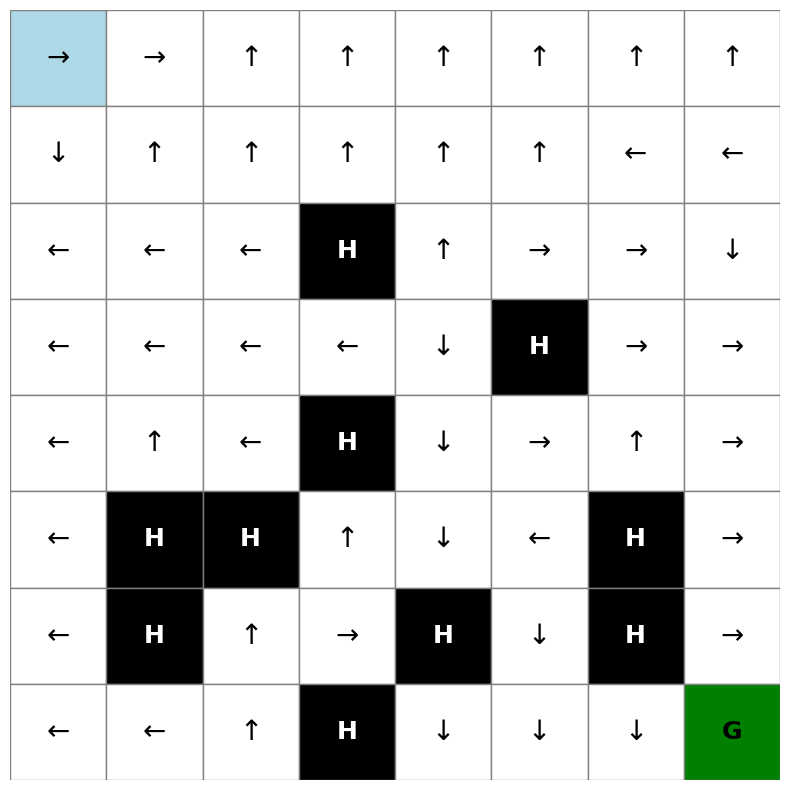

'\nNote: How are the graphs so weird for IS, i guess due to the lack of long trajectories, so itll need more eps+iters\n'

In [9]:
"""Here, change oneshot_eval to monte_carlo_eval to switch evaluation modes"""

env = build_env(slippery=True)
policy, episode_rewards, episode_lengths = policy_iter(env, eval_method=mc_eval_importance_sampling)
policy = np.reshape(policy, (SIZE, SIZE))
print(policy)

print(env.unwrapped.desc)

plot_frozenlake_policy(policy, env.unwrapped.desc)

"""
Note: How are the graphs so weird for IS, i guess due to the lack of long trajectories, so itll need more eps+iters
"""

In [ ]:
"""ye worked with more iters, infact very good quality"""

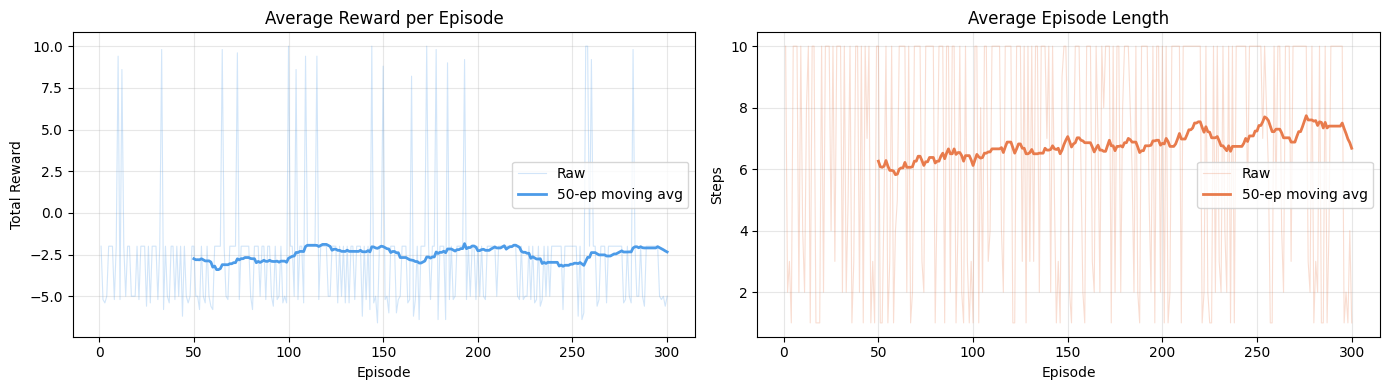

In [10]:
plot_mc_stats(episode_rewards, episode_lengths)

In [ ]:
"""avg reward stays almost const which is odd, but average episode length consistently increases which makes sense"""